In [28]:
# On nettoie tout pour repartir sur une base saine
!pip uninstall -y numpy scipy scikit-learn pandas-ta yfinance

# On installe dans cet ordre précis pour forcer la compatibilité NumPy 1.x
!pip install numpy==1.26.4
!pip install scipy==1.12.0
!pip install scikit-learn==1.4.2
!pip install yfinance
# On installe pandas-ta sans vérifier les dépendances pour éviter qu'il ne force NumPy 2.x
!pip install pandas-ta --no-deps
!pip install keras-tcn

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: scipy 1.12.0
Uninstalling scipy-1.12.0:
  Successfully uninstalled scipy-1.12.0
Found existing installation: scikit-learn 1.4.2
Uninstalling scikit-learn-1.4.2:
  Successfully uninstalled scikit-learn-1.4.2
Found existing installation: pandas-ta 0.4.71b0
Uninstalling pandas-ta-0.4.71b0:
  Successfully uninstalled pandas-ta-0.4.71b0
Found existing installation: yfinance 1.2.1
Uninstalling yfinance-1.2.1:
  Successfully uninstalled yfinance-1.2.1
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
configspace 1.2.2 requires scipy, which

In [29]:
import numpy as np
import pandas as pd
import pandas_ta as ta
from sklearn.svm import SVC
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten, SimpleRNN, BatchNormalization, Bidirectional, Attention, GlobalAveragePooling1D, Add, MultiHeadAttention
from tensorflow.keras.utils import to_categorical
from tcn import TCN
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.utils import class_weight
import matplotlib.cm as cm
from sklearn.utils.class_weight import compute_class_weight
import requests

In [30]:
TICKER = "SPY"
WINDOW_SIZE = 21
HORIZON = 7
THRESHOLD = 0.017   # 0.0 = binaire (hausse/baisse), >0 = triple barrière avec HOLD

# --- 2. PRÉPARATION DES DONNÉES ---
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- Features originales ---
df['returns']    = df['Close'].pct_change()
df['RSI']        = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd           = ta.macd(df['Close'])
df['MACD']     = macd.iloc[:, 0] / df['Close']

stoch          = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH']    = stoch.iloc[:, 0] / 100

bbands         = ta.bbands(df['Close'], length=20, std=2)
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx            = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX']      = adx.iloc[:, 0] / 100

# --- Features enrichies ---
df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_3']      = df['Close'].pct_change(3)
df['momentum_7']      = df['Close'].pct_change(7)
df['momentum_14']     = df['Close'].pct_change(14)

# VIX
vix_raw = yf.download("^VIX", start="2018-01-01", auto_adjust=True)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw['Close'].copy()
vix.index = pd.to_datetime(vix.index).tz_localize(None)
df.index = pd.to_datetime(df.index).tz_localize(None)
df['vix'] = vix.reindex(df.index).ffill() / 100

# Taux 10 ans US
tnx_raw = yf.download("^TNX", start="2018-01-01", auto_adjust=True)
if isinstance(tnx_raw.columns, pd.MultiIndex):
    tnx_raw.columns = tnx_raw.columns.get_level_values(0)
tnx = tnx_raw['Close'].copy()
tnx.index = pd.to_datetime(tnx.index).tz_localize(None)
df['tnx'] = tnx.reindex(df.index).ffill() / 100

# Fear & Greed
fg = requests.get("https://api.alternative.me/fng/?limit=2000&format=json").json()
fg_df = pd.DataFrame(fg['data'])
fg_df['timestamp'] = pd.to_datetime(fg_df['timestamp'].astype(int), unit='s')
fg_df = fg_df.set_index('timestamp')[['value']].rename(columns={'value': 'fear_greed'})
fg_df['fear_greed'] = fg_df['fear_greed'].astype(float) / 100
df = df.join(fg_df, how='left')
df['fear_greed'] = df['fear_greed'].ffill()

df.dropna(inplace=True)

# --- Labeling ---
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

# --- 2. PRÉPARATION DES DONNÉES (Suite - Nouveau Labeling) ---

# Paramètres de la Triple Barrière
# On utilise THRESHOLD comme barrière de profit et de perte
def get_triple_barrier_labels(df, horizon, threshold):
    labels = []
    prices = df['Close'].values
    
    for i in range(len(prices) - horizon):
        price_start = prices[i]
        upper_barrier = price_start * (1 + threshold)
        lower_barrier = price_start * (1 - threshold)
        
        # On extrait les prix sur les 'horizon' prochains jours
        future_prices = prices[i+1 : i+horizon+1]
        
        found_label = 1 # Par défaut : HOLD (barrière temporelle touchée)
        
        for p in future_prices:
            if p >= upper_barrier:
                found_label = 2 # BUY (Profit touché en premier)
                break
            elif p <= lower_barrier:
                found_label = 0 # SELL (Perte touchée en premier)
                break
        
        labels.append(found_label)
    
    return labels

# Application du nouveau labeling
NUM_CLASSES = 3
CLASS_NAMES = ["SELL", "HOLD", "BUY"]

# On calcule les labels
labels_list = get_triple_barrier_labels(df, HORIZON, THRESHOLD)

# On doit aligner le dataframe (on perd les 'HORIZON' dernières lignes)
df = df.iloc[:len(labels_list)].copy()
df['target'] = labels_list

print(f"Distribution des classes (Triple Barrière):\n{df['target'].value_counts()}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Distribution des classes (Triple Barrière):
target
2    389
0    326
1    321
Name: count, dtype: int64


In [31]:
TICKER = "SPY"
WINDOW_SIZE = 21
HORIZON = 7
THRESHOLD = 0.017   # 0.0 = binaire (hausse/baisse), >0 = triple barrière avec HOLD

# --- 2. PRÉPARATION DES DONNÉES ---
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# --- Features originales ---
df['returns']    = df['Close'].pct_change()
df['RSI']        = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()

macd           = ta.macd(df['Close'])
df['MACD']     = macd.iloc[:, 0] / df['Close']

stoch          = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH']    = stoch.iloc[:, 0] / 100

bbands         = ta.bbands(df['Close'], length=20, std=2)
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']

adx            = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX']      = adx.iloc[:, 0] / 100

# --- Features enrichies ---
df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_3']      = df['Close'].pct_change(3)
df['momentum_7']      = df['Close'].pct_change(7)
df['momentum_14']     = df['Close'].pct_change(14)

# VIX
vix_raw = yf.download("^VIX", start="2018-01-01", auto_adjust=True)
if isinstance(vix_raw.columns, pd.MultiIndex):
    vix_raw.columns = vix_raw.columns.get_level_values(0)
vix = vix_raw['Close'].copy()
vix.index = pd.to_datetime(vix.index).tz_localize(None)
df.index = pd.to_datetime(df.index).tz_localize(None)
df['vix'] = vix.reindex(df.index).ffill() / 100

# Taux 10 ans US
tnx_raw = yf.download("^TNX", start="2018-01-01", auto_adjust=True)
if isinstance(tnx_raw.columns, pd.MultiIndex):
    tnx_raw.columns = tnx_raw.columns.get_level_values(0)
tnx = tnx_raw['Close'].copy()
tnx.index = pd.to_datetime(tnx.index).tz_localize(None)
df['tnx'] = tnx.reindex(df.index).ffill() / 100

# Fear & Greed
fg = requests.get("https://api.alternative.me/fng/?limit=2000&format=json").json()
fg_df = pd.DataFrame(fg['data'])
fg_df['timestamp'] = pd.to_datetime(fg_df['timestamp'].astype(int), unit='s')
fg_df = fg_df.set_index('timestamp')[['value']].rename(columns={'value': 'fear_greed'})
fg_df['fear_greed'] = fg_df['fear_greed'].astype(float) / 100
df = df.join(fg_df, how='left')
df['fear_greed'] = df['fear_greed'].ffill()

df.dropna(inplace=True)

# --- Labeling ---
future_change = df['Close'].shift(-HORIZON) / df['Close'] - 1

# --- 2. PRÉPARATION DES DONNÉES (Suite - Nouveau Labeling) ---

# Paramètres de la Triple Barrière
# On utilise THRESHOLD comme barrière de profit et de perte
def get_triple_barrier_labels(df, horizon, threshold):
    labels = []
    prices = df['Close'].values
    
    for i in range(len(prices) - horizon):
        price_start = prices[i]
        upper_barrier = price_start * (1 + threshold)
        lower_barrier = price_start * (1 - threshold)
        
        # On extrait les prix sur les 'horizon' prochains jours
        future_prices = prices[i+1 : i+horizon+1]
        
        found_label = 1 # Par défaut : HOLD (barrière temporelle touchée)
        
        for p in future_prices:
            if p >= upper_barrier:
                found_label = 2 # BUY (Profit touché en premier)
                break
            elif p <= lower_barrier:
                found_label = 0 # SELL (Perte touchée en premier)
                break
        
        labels.append(found_label)
    
    return labels

# Application du nouveau labeling
NUM_CLASSES = 3
CLASS_NAMES = ["SELL", "HOLD", "BUY"]

# On calcule les labels
labels_list = get_triple_barrier_labels(df, HORIZON, THRESHOLD)

# On doit aligner le dataframe (on perd les 'HORIZON' dernières lignes)
df = df.iloc[:len(labels_list)].copy()
df['target'] = labels_list

print(f"Distribution des classes (Triple Barrière):\n{df['target'].value_counts()}")

# --- Séquençage ---
features = [
    'returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width',
    'volume_change', 'volume_ma_ratio', 'high_low_range', 'close_position',
    'momentum_3', 'momentum_7', 'momentum_14',
    'vix', 'tnx', 'fear_greed'
]

X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
y_cat = to_categorical(y, num_classes=NUM_CLASSES)

# --- Split temporel ---
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_cat[:split], y_cat[split:]
y_test_labels   = y[split:]

# --- Class weights ---
classes       = np.unique(y[:split])
weights_array = compute_class_weight('balanced', classes=classes, y=y[:split])
class_weights = dict(zip(classes.astype(int), weights_array))
print(f"Class weights: {class_weights}")
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}, features: {len(features)}")

# 1. Préparation spécifique : on aplatit les fenêtres temporelles
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Le SVM est très sensible à l'échelle des données
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# 3. Entraînement avec gestion du déséquilibre (class_weight)
print("🚀 Training SVM (RBF Kernel)...")
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, class_weight='balanced')
svm_model.fit(X_train_scaled, y[:split]) # On utilise y non-categorical pour sklearn

# 4. Prédiction des probabilités pour ton tableau de comparaison
probas_svm = svm_model.predict_proba(X_test_scaled)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Distribution des classes (Triple Barrière):
target
2    389
0    326
1    321
Name: count, dtype: int64
Class weights: {0: 1.0870147255689424, 1: 1.1768115942028985, 2: 0.8128128128128128}
X_train: (812, 21, 17), X_test: (203, 21, 17), features: 17
🚀 Training SVM (RBF Kernel)...


In [32]:
# On ne garde que les moments où le SVM est "sûr" (> 60%)
high_conf_idx = np.where(probas_svm.max(axis=1) > 0.60)[0]
y_pred_high_conf = np.argmax(probas_svm[high_conf_idx], axis=1)
y_true_high_conf = y_test_labels[high_conf_idx]

from sklearn.metrics import accuracy_score
if len(high_conf_idx) > 0:
    print(f"Accuracy sur signaux forts (>60%): {accuracy_score(y_true_high_conf, y_pred_high_conf):.2%}")
    print(f"Nombre de trades identifiés : {len(high_conf_idx)}")
else:
    print("Aucun signal assez fort.")

Accuracy sur signaux forts (>60%): 43.94%
Nombre de trades identifiés : 66


In [33]:
# 1. On récupère les indices des signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.60
trades_idx = np.where(high_conf_mask)[0]

# 2. On crée un DataFrame de performance
df_test = df.iloc[split + WINDOW_SIZE:].copy()
df_test = df_test.iloc[trades_idx]

df_test['pred'] = np.argmax(probas_svm[high_conf_mask], axis=1)
df_test['real_change'] = (df['Close'].shift(-HORIZON) / df['Close'] - 1).iloc[split + WINDOW_SIZE + trades_idx].values

# 3. Calcul du profit (simplifié)
# On gagne si (pred=2 et change > THRESHOLD) ou (pred=0 et change < -THRESHOLD)
def calculate_profit(row):
    if row['pred'] == 2: return row['real_change'] # Long
    if row['pred'] == 0: return -row['real_change'] # Short
    return 0

df_test['profit'] = df_test.apply(calculate_profit, axis=1)

print(f"Profit cumulé sur 21 trades : {df_test['profit'].sum():.2%}")
print(f"Profit moyen par trade : {df_test['profit'].mean():.2%}")

Profit cumulé sur 21 trades : -16.28%
Profit moyen par trade : -0.28%


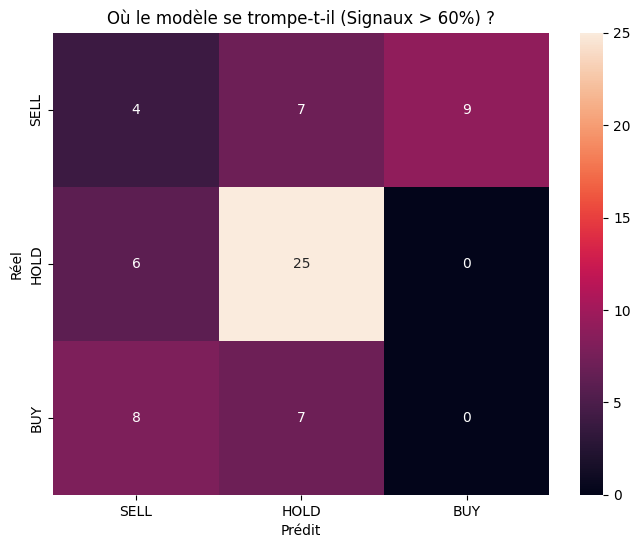

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# On filtre les signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.60
y_pred_strong = np.argmax(probas_svm[high_conf_mask], axis=1)
y_true_strong = y_test_labels[high_conf_mask]

cm = confusion_matrix(y_true_strong, y_pred_strong)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Où le modèle se trompe-t-il (Signaux > 60%) ?")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

---

In [35]:
# --- 1. CONFIGURATION ---
TICKER = "SPY"
WINDOW_SIZE = 21
HORIZON = 7
THRESHOLD = 0.017 

# --- 2. PRÉPARATION DES DONNÉES ---
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Features
df['returns']    = df['Close'].pct_change()
df['RSI']        = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()
macd = ta.macd(df['Close'])
df['MACD'] = macd.iloc[:, 0] / df['Close']
stoch = ta.stoch(df['High'], df['Low'], df['Close'])
df['STOCH'] = stoch.iloc[:, 0] / 100
bbands = ta.bbands(df['Close'], length=20, std=2)
df['BB_width'] = (bbands.iloc[:, 2] - bbands.iloc[:, 0]) / df['Close']
adx = ta.adx(df['High'], df['Low'], df['Close'])
df['ADX'] = adx.iloc[:, 0] / 100

# Features enrichies
df['volume_change']   = df['Volume'].pct_change()
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['high_low_range']  = (df['High'] - df['Low']) / df['Close']
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_3']      = df['Close'].pct_change(3)
df['momentum_7']      = df['Close'].pct_change(7)
df['momentum_14']     = df['Close'].pct_change(14)

# Données Macro (VIX, TNX, Fear & Greed)
for t, name in [("^VIX", "vix"), ("^TNX", "tnx")]:
    raw = yf.download(t, start="2018-01-01", auto_adjust=True)
    if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)
    series = raw['Close'].copy()
    series.index = pd.to_datetime(series.index).tz_localize(None)
    df[name] = series.reindex(df.index).ffill() / 100

fg = requests.get("https://api.alternative.me/fng/?limit=2000&format=json").json()
fg_df = pd.DataFrame(fg['data'])
fg_df['timestamp'] = pd.to_datetime(fg_df['timestamp'].astype(int), unit='s')
fg_df = fg_df.set_index('timestamp')[['value']].rename(columns={'value': 'fear_greed'})
df = df.join(fg_df['fear_greed'].astype(float) / 100, how='left').ffill()
df.dropna(inplace=True)

# --- 3. LABELING TRIPLE BARRIÈRE ---
def get_triple_barrier_labels(df, horizon, threshold):
    labels = []
    prices = df['Close'].values
    for i in range(len(prices) - horizon):
        p_start = prices[i]
        upper, lower = p_start * (1 + threshold), p_start * (1 - threshold)
        future_window = prices[i+1 : i+horizon+1]
        found_label = 1 # HOLD
        for p in future_window:
            if p >= upper: found_label = 2; break
            elif p <= lower: found_label = 0; break
        labels.append(found_label)
    return labels

labels_list = get_triple_barrier_labels(df, HORIZON, THRESHOLD)
df = df.iloc[:len(labels_list)].copy()
df['target'] = labels_list

# --- 4. SÉQUENÇAGE & SPLIT ---
features = ['returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 'BB_width', 
            'volume_change', 'volume_ma_ratio', 'high_low_range', 'close_position', 
            'momentum_3', 'momentum_7', 'momentum_14', 'vix', 'tnx', 'fear_greed']

X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)
X_train_flat = X[:split].reshape(split, -1)
X_test_flat = X[split:].reshape(len(X)-split, -1)
y_train, y_test = y[:split], y[split:]

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# --- 5. ENTRAÎNEMENT SVM ---
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
svm_model = SVC(kernel='rbf', C=1.0, probability=True, class_weight=dict(zip(np.unique(y_train), weights)))
svm_model.fit(X_train_scaled, y_train)

# --- 6. RÉSULTATS G1G2 ---
probas = svm_model.predict_proba(X_test_scaled)
high_conf = probas.max(axis=1) > 0.60
if high_conf.any():
    acc = accuracy_score(y_test[high_conf], np.argmax(probas[high_conf], axis=1))
    print(f"✅ Accuracy signaux forts (>60%): {acc:.2%}")
    print(f"📈 Nombre de trades : {high_conf.sum()}")
else:
    print("⚠️ Aucun signal > 60% de confiance.")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


✅ Accuracy signaux forts (>60%): 45.59%
📈 Nombre de trades : 68


In [36]:
# On ne garde que les moments où le SVM est "sûr" (> 60%)
high_conf_idx = np.where(probas_svm.max(axis=1) > 0.60)[0]
y_pred_high_conf = np.argmax(probas_svm[high_conf_idx], axis=1)
y_true_high_conf = y_test_labels[high_conf_idx]

from sklearn.metrics import accuracy_score
if len(high_conf_idx) > 0:
    print(f"Accuracy sur signaux forts (>60%): {accuracy_score(y_true_high_conf, y_pred_high_conf):.2%}")
    print(f"Nombre de trades identifiés : {len(high_conf_idx)}")
else:
    print("Aucun signal assez fort.")

Accuracy sur signaux forts (>60%): 43.94%
Nombre de trades identifiés : 66


In [37]:
# 1. On récupère les indices des signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.60
trades_idx = np.where(high_conf_mask)[0]

# 2. On crée un DataFrame de performance
df_test = df.iloc[split + WINDOW_SIZE:].copy()
df_test = df_test.iloc[trades_idx]

df_test['pred'] = np.argmax(probas_svm[high_conf_mask], axis=1)
df_test['real_change'] = (df['Close'].shift(-HORIZON) / df['Close'] - 1).iloc[split + WINDOW_SIZE + trades_idx].values

# 3. Calcul du profit (simplifié)
# On gagne si (pred=2 et change > THRESHOLD) ou (pred=0 et change < -THRESHOLD)
def calculate_profit(row):
    if row['pred'] == 2: return row['real_change'] # Long
    if row['pred'] == 0: return -row['real_change'] # Short
    return 0

df_test['profit'] = df_test.apply(calculate_profit, axis=1)

print(f"Profit cumulé sur 21 trades : {df_test['profit'].sum():.2%}")
print(f"Profit moyen par trade : {df_test['profit'].mean():.2%}")

Profit cumulé sur 21 trades : -4.91%
Profit moyen par trade : -0.31%


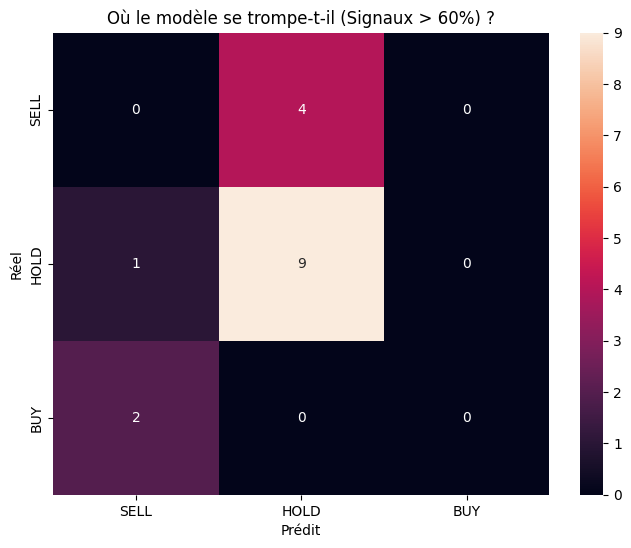

In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# On filtre les signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.60
y_pred_strong = np.argmax(probas_svm[high_conf_mask], axis=1)
y_true_strong = y_test_labels[high_conf_mask]

cm = confusion_matrix(y_true_strong, y_pred_strong)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Où le modèle se trompe-t-il (Signaux > 60%) ?")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

---

In [42]:
# --- 1. CONFIGURATION G1G2 ---
TICKER = "SPY"
WINDOW_SIZE = 21
HORIZON = 7
VOL_MULTIPLIER = 1.2  # Augmenter pour avoir plus de "HOLD" (sélectivité)

# --- 2. TÉLÉCHARGEMENT ET FEATURES ---
df = yf.download(TICKER, start="2022-01-01", auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Indicateurs Techniques
df['returns'] = df['Close'].pct_change()
df['RSI'] = ta.rsi(df['Close'], length=14) / 100
df['Volatility'] = df['returns'].rolling(window=10).std()
df['MACD'] = ta.macd(df['Close']).iloc[:, 0] / df['Close']
df['STOCH'] = ta.stoch(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100
df['ADX'] = ta.adx(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100

# Features de Volume et Momentum
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['close_position'] = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_7'] = df['Close'].pct_change(7)

# Données Macro (VIX, TNX)
for t, name in [("^VIX", "vix"), ("^TNX", "tnx")]:
    raw = yf.download(t, start="2020-01-01", auto_adjust=True)
    if isinstance(raw.columns, pd.MultiIndex): raw.columns = raw.columns.get_level_values(0)
    df[name] = raw['Close'].reindex(df.index).ffill() / 100

# Sentiment (Fear & Greed)
try:
    fg_data = requests.get("https://api.alternative.me/fng/?limit=2000&format=json").json()['data']
    fg_df = pd.DataFrame(fg_data)
    fg_df['timestamp'] = pd.to_datetime(fg_df['timestamp'].astype(int), unit='s')
    fg_df = fg_df.set_index('timestamp')[['value']].rename(columns={'value': 'fear_greed'})
    df = df.join(fg_df['fear_greed'].astype(float) / 100, how='left').ffill()
except:
    print("Erreur API Fear & Greed, feature ignorée.")

df.dropna(inplace=True)

# --- 3. NOUVEAU LABELING DYNAMIQUE (TRIPLE BARRIÈRE) ---
def get_dynamic_labels(df, horizon, multiplier):
    prices = df['Close'].values
    # Volatilité rolling pour adapter les barrières au marché
    vol = df['returns'].rolling(20).std().values
    labels = []
    
    for i in range(len(prices) - horizon):
        p_start = prices[i]
        # Seuil adapté : Volatilité * Racine(Horizon) * Multiplicateur
        threshold = vol[i] * np.sqrt(horizon) * multiplier
        
        upper = p_start * (1 + threshold)
        lower = p_start * (1 - threshold)
        
        future_prices = prices[i+1 : i+horizon+1]
        label = 1 # HOLD (Barrière temporelle)
        
        for p in future_prices:
            if p >= upper: label = 2; break # BUY
            elif p <= lower: label = 0; break # SELL
        labels.append(label)
    return labels

labels_list = get_dynamic_labels(df, HORIZON, VOL_MULTIPLIER)
df = df.iloc[:len(labels_list)].copy()
df['target'] = labels_list

print(f"\nDistribution des classes :\n{df['target'].value_counts()}")

# --- 4. PRÉPARATION SVM (FLATTENING) ---
features_list = ['returns', 'RSI', 'Volatility', 'ADX', 'MACD', 'STOCH', 
                 'volume_ma_ratio', 'close_position', 'momentum_7', 'vix', 'tnx', 'fear_greed']

X, y = [], []
for i in range(len(df) - WINDOW_SIZE):
    X.append(df[features_list].iloc[i:i+WINDOW_SIZE].values)
    y.append(df['target'].iloc[i+WINDOW_SIZE])

X, y = np.array(X), np.array(y)
split = int(len(X) * 0.8)

# Aplatir pour le SVM : (Samples, Window * Features)
X_train_flat = X[:split].reshape(split, -1)
X_test_flat = X[split:].reshape(len(X)-split, -1)
y_train, y_test = y[:split], y[split:]

# Scaling (Crucial pour SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_test_scaled = scaler.transform(X_test_flat)

# --- 5. ENTRAÎNEMENT SVM ---
print("\n🚀 Entraînement du SVM G1G2...")
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
svm_model = SVC(
    kernel='rbf', 
    C=10.0,           # On augmente C pour forcer le modèle à classer correctement les BUY/SELL
    gamma='scale', 
    probability=True, 
    class_weight='balanced' # Indispensable ici
    )
svm_model.fit(X_train_scaled, y_train)

# --- 6. ANALYSE DES PERFORMANCES ---
probas = svm_model.predict_proba(X_test_scaled)
preds = np.argmax(probas, axis=1)

# Filtre de confiance G1G2 (> 60%)
high_conf_mask = probas.max(axis=1) > 0.60
if high_conf_mask.any():
    acc_strong = accuracy_score(y_test[high_conf_mask], preds[high_conf_mask])
    print(f"\n🎯 Accuracy (Confiance > 60%) : {acc_strong:.2%}")
    print(f"📊 Nombre de trades identifiés : {high_conf_mask.sum()}")
else:
    print("\n⚠️ Aucun signal n'a dépassé 60% de confiance.")

print("\n--- Rapport de Classification Global ---")
print(classification_report(y_test, preds, target_names=["SELL", "HOLD", "BUY"]))

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Distribution des classes :
target
1    682
0    179
2    175
Name: count, dtype: int64

🚀 Entraînement du SVM G1G2...

🎯 Accuracy (Confiance > 60%) : 54.97%
📊 Nombre de trades identifiés : 151

--- Rapport de Classification Global ---
              precision    recall  f1-score   support

        SELL       0.11      0.14      0.12        43
        HOLD       0.65      0.70      0.67       131
         BUY       0.12      0.03      0.05        29

    accuracy                           0.49       203
   macro avg       0.30      0.29      0.28       203
weighted avg       0.46      0.49      0.47       203



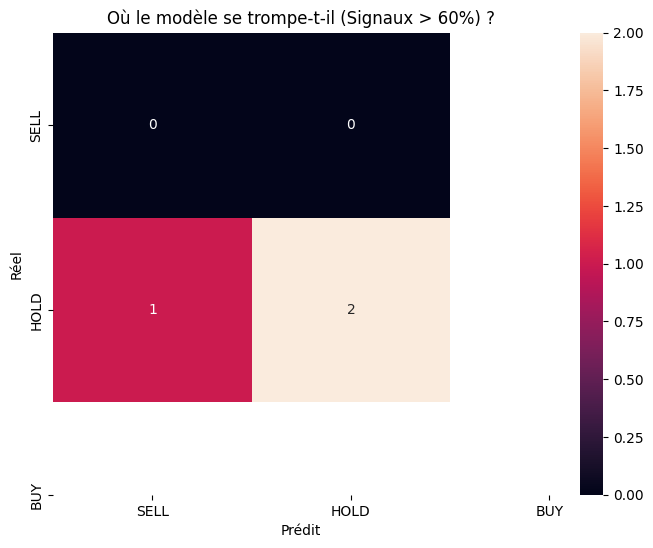

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# On filtre les signaux forts
high_conf_mask = probas_svm.max(axis=1) > 0.75
y_pred_strong = np.argmax(probas_svm[high_conf_mask], axis=1)
y_true_strong = y_test_labels[high_conf_mask]

cm = confusion_matrix(y_true_strong, y_pred_strong)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Où le modèle se trompe-t-il (Signaux > 60%) ?")
plt.ylabel('Réel')
plt.xlabel('Prédit')
plt.show()

[*********************100%***********************]  1 of 1 completed

📥 Téléchargement des données...



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed



Distribution classes (labelling adaptatif) :
target
BUY     822
SELL    499
HOLD    227
Name: count, dtype: int64

🔄 Walk-forward validation (5 folds)...
  Fold 1: acc=50.9%  f1=0.23  trades=108  profit=50.83%
  Fold 2: acc=40.5%  f1=0.29  trades=168  profit=-30.43%
  Fold 3: acc=39.6%  f1=0.25  trades=139  profit=-29.05%
  Fold 4: acc=43.6%  f1=0.28  trades=165  profit=46.72%
  Fold 5: acc=41.6%  f1=0.30  trades=150  profit=64.04%

📊 RÉSUMÉ WALK-FORWARD (5 folds)
Accuracy moyenne (signaux forts) : 43.2%
F1-macro moyen                   : 0.27
Trades totaux identifiés         : 730
Profit cumulé modèle (sommé)     : 102.11%
Benchmark Buy & Hold (même période): 79.70%

✅ Bat le benchmark

📋 Rapport de classification agrégé (tous folds)
              precision    recall  f1-score   support

        SELL       0.30      0.31      0.30       245
        HOLD       0.00      0.00      0.00       102
         BUY       0.50      0.61      0.55       387

    accuracy                        

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/svm_conclusion.png'

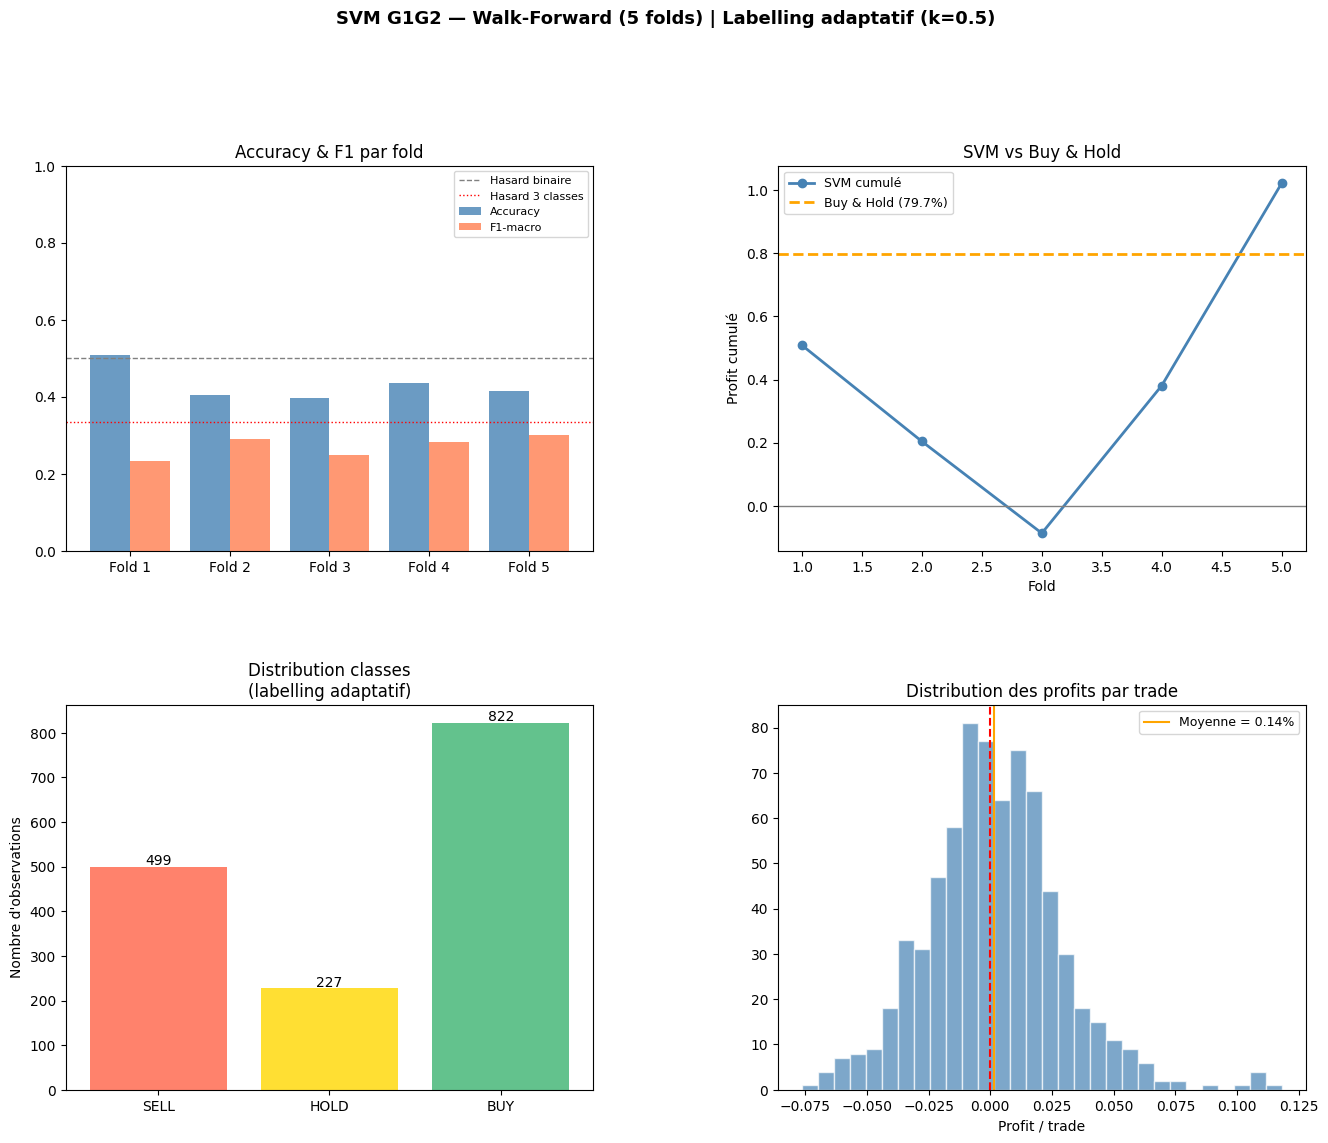

In [47]:
"""
G1G2 - SVM Conclusion Cell
Teste : labelling adaptatif + walk-forward validation + benchmark Buy&Hold
Base : cellule 13 (VIX/TNX, depuis 2020)
"""

import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# ─────────────────────────────────────────────
# 1. CONFIG
# ─────────────────────────────────────────────
TICKER       = "SPY"
WINDOW_SIZE  = 21
HORIZON      = 7
VOL_K        = 0.5    # threshold adaptatif = VOL_K × volatilité réalisée 10j
N_FOLDS      = 5      # nombre de fenêtres walk-forward
CONF_THRESH  = 0.60

CLASS_NAMES  = ["SELL", "HOLD", "BUY"]


# ─────────────────────────────────────────────
# 2. DONNÉES + FEATURES (identique cellule 13)
# ─────────────────────────────────────────────
print("📥 Téléchargement des données...")
df = yf.download(TICKER, start="2020-01-01", auto_adjust=True)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df['returns']         = df['Close'].pct_change()
df['RSI']             = ta.rsi(df['Close'], length=14) / 100
df['Volatility']      = df['returns'].rolling(window=10).std()
df['MACD']            = ta.macd(df['Close']).iloc[:, 0] / df['Close']
df['STOCH']           = ta.stoch(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100
df['ADX']             = ta.adx(df['High'], df['Low'], df['Close']).iloc[:, 0] / 100
df['volume_ma_ratio'] = df['Volume'] / df['Volume'].rolling(20).mean()
df['close_position']  = (df['Close'] - df['Low']) / (df['High'] - df['Low'] + 1e-9)
df['momentum_7']      = df['Close'].pct_change(7)

for ticker, name in [("^VIX", "VIX"), ("^TNX", "TNX")]:
    try:
        tmp = yf.download(ticker, start="2020-01-01", auto_adjust=True)["Close"]
        if isinstance(tmp, pd.DataFrame): tmp = tmp.iloc[:, 0]
        df[name] = tmp.reindex(df.index).ffill() / 100
    except:
        df[name] = 0.0

df['BB_width'] = (
    ta.bbands(df['Close'], length=20, std=2).iloc[:, 2] -
    ta.bbands(df['Close'], length=20, std=2).iloc[:, 0]
) / df['Close']

FEATURES = ['returns', 'RSI', 'Volatility', 'MACD', 'STOCH', 'ADX',
            'volume_ma_ratio', 'close_position', 'momentum_7',
            'VIX', 'TNX', 'BB_width']


# ─────────────────────────────────────────────
# 3. LABELLING ADAPTATIF
#    threshold = VOL_K × volatilité réalisée 10j
#    (au lieu d'un seuil fixe 1.7%)
# ─────────────────────────────────────────────
def make_adaptive_labels(df, horizon=HORIZON, vol_k=VOL_K):
    fwd_return   = df['Close'].shift(-horizon) / df['Close'] - 1
    adaptive_thr = vol_k * df['Volatility']   # seuil dynamique par jour

    labels = np.where(fwd_return >  adaptive_thr,  2,   # BUY
              np.where(fwd_return < -adaptive_thr,  0,   # SELL
                       1))                               # HOLD
    return labels

df['target'] = make_adaptive_labels(df)
df.dropna(inplace=True)

print("\nDistribution classes (labelling adaptatif) :")
print(pd.Series(df['target']).value_counts().rename({0:"SELL",1:"HOLD",2:"BUY"}))


# ─────────────────────────────────────────────
# 4. CONSTRUCTION DES SÉQUENCES
# ─────────────────────────────────────────────
def build_sequences(df, features, window=WINDOW_SIZE):
    X, y, dates = [], [], []
    feat_arr = df[features].values
    tgt_arr  = df['target'].values
    idx_arr  = df.index

    for i in range(window, len(df)):
        X.append(feat_arr[i-window:i].flatten())
        y.append(tgt_arr[i])
        dates.append(idx_arr[i])

    return np.array(X), np.array(y), dates

X_all, y_all, dates_all = build_sequences(df, FEATURES)
dates_all = pd.DatetimeIndex(dates_all)


# ─────────────────────────────────────────────
# 5. WALK-FORWARD VALIDATION
#    On découpe chronologiquement en N_FOLDS fenêtres
#    Chaque fold : train sur passé, test sur futur immédiat
# ─────────────────────────────────────────────
print(f"\n🔄 Walk-forward validation ({N_FOLDS} folds)...")

fold_size   = len(X_all) // (N_FOLDS + 1)
results_wf  = []   # (fold, accuracy, f1_macro, n_trades, profit)
all_preds   = []
all_trues   = []
all_profits = []

close_arr = df['Close'].values
close_idx = df.index

for fold in range(N_FOLDS):
    train_end = fold_size * (fold + 1)
    test_start = train_end
    test_end   = test_start + fold_size

    X_tr, y_tr = X_all[:train_end],          y_all[:train_end]
    X_te, y_te = X_all[test_start:test_end], y_all[test_start:test_end]
    d_te       = dates_all[test_start:test_end]

    # Scale
    scaler = RobustScaler()
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)

    # Class weights
    cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
    cw_dict = dict(enumerate(cw))

    # SVM
    svm = SVC(kernel='rbf', C=10, gamma='scale',
              probability=True, class_weight=cw_dict, random_state=42)
    svm.fit(X_tr_s, y_tr)
    probas = svm.predict_proba(X_te_s)

    # Signaux forts seulement
    conf_mask    = probas.max(axis=1) > CONF_THRESH
    y_pred_conf  = np.argmax(probas[conf_mask], axis=1)
    y_true_conf  = y_te[conf_mask]
    dates_conf   = d_te[conf_mask]

    # Profit simplifié (long si BUY, short si SELL, cash si HOLD)
    profits = []
    for d, pred in zip(dates_conf, y_pred_conf):
        loc = close_idx.get_loc(d)
        if loc + HORIZON < len(close_arr):
            fwd = close_arr[loc + HORIZON] / close_arr[loc] - 1
            if pred == 2: profits.append(fwd)
            elif pred == 0: profits.append(-fwd)
            else: profits.append(0.0)

    acc    = accuracy_score(y_true_conf, y_pred_conf) if len(y_true_conf) > 0 else 0
    f1     = f1_score(y_true_conf, y_pred_conf, average='macro', zero_division=0) if len(y_true_conf) > 0 else 0
    profit = sum(profits)
    n_tr   = len(profits)

    results_wf.append((fold+1, acc, f1, n_tr, profit))
    all_preds.extend(y_pred_conf)
    all_trues.extend(y_true_conf)
    all_profits.extend(profits)

    print(f"  Fold {fold+1}: acc={acc:.1%}  f1={f1:.2f}  trades={n_tr}  profit={profit:.2%}")


# ─────────────────────────────────────────────
# 6. BENCHMARK BUY & HOLD
# ─────────────────────────────────────────────
# Sur la même période que les folds de test
test_start_date = dates_all[fold_size]
bh_prices = df.loc[test_start_date:, 'Close']
bh_return = bh_prices.iloc[-1] / bh_prices.iloc[0] - 1

# Profit cumulé du modèle (sans compounding pour comparaison équitable)
model_cumprofit = sum(all_profits)

print(f"\n{'='*50}")
print(f"📊 RÉSUMÉ WALK-FORWARD ({N_FOLDS} folds)")
print(f"{'='*50}")
print(f"Accuracy moyenne (signaux forts) : {np.mean([r[1] for r in results_wf]):.1%}")
print(f"F1-macro moyen                   : {np.mean([r[2] for r in results_wf]):.2f}")
print(f"Trades totaux identifiés         : {sum(r[3] for r in results_wf)}")
print(f"Profit cumulé modèle (sommé)     : {model_cumprofit:.2%}")
print(f"Benchmark Buy & Hold (même période): {bh_return:.2%}")

beat = "✅ Bat le benchmark" if model_cumprofit > bh_return else "❌ Ne bat pas le benchmark"
print(f"\n{beat}")


# ─────────────────────────────────────────────
# 7. RAPPORT DE CLASSIFICATION AGRÉGÉ
# ─────────────────────────────────────────────
print(f"\n{'='*50}")
print("📋 Rapport de classification agrégé (tous folds)")
print(f"{'='*50}")
print(classification_report(all_trues, all_preds,
                             target_names=CLASS_NAMES, zero_division=0))


# ─────────────────────────────────────────────
# 8. VISUALISATION
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 2, hspace=0.4, wspace=0.35)

# --- 8a. Accuracy & F1 par fold ---
ax1 = fig.add_subplot(gs[0, 0])
folds    = [r[0] for r in results_wf]
accs     = [r[1] for r in results_wf]
f1s      = [r[2] for r in results_wf]
x        = np.arange(len(folds))
ax1.bar(x - 0.2, accs, 0.4, label='Accuracy', color='steelblue', alpha=0.8)
ax1.bar(x + 0.2, f1s,  0.4, label='F1-macro',  color='coral',    alpha=0.8)
ax1.axhline(0.5, color='gray', linestyle='--', lw=1, label='Hasard binaire')
ax1.axhline(1/3, color='red',  linestyle=':',  lw=1, label='Hasard 3 classes')
ax1.set_xticks(x); ax1.set_xticklabels([f"Fold {f}" for f in folds])
ax1.set_ylim(0, 1); ax1.set_title("Accuracy & F1 par fold"); ax1.legend(fontsize=8)

# --- 8b. Profit cumulé fold vs BH ---
ax2 = fig.add_subplot(gs[0, 1])
profits_per_fold = [r[4] for r in results_wf]
cumulative       = np.cumsum(profits_per_fold)
ax2.plot(folds, cumulative, 'o-', color='steelblue', lw=2, label='SVM cumulé')
ax2.axhline(bh_return, color='orange', lw=2, linestyle='--',
            label=f'Buy & Hold ({bh_return:.1%})')
ax2.axhline(0, color='gray', lw=1)
ax2.set_xlabel("Fold"); ax2.set_ylabel("Profit cumulé")
ax2.set_title("SVM vs Buy & Hold"); ax2.legend(fontsize=9)

# --- 8c. Distribution des classes (adaptatif vs fixe) ---
ax3 = fig.add_subplot(gs[1, 0])
counts = pd.Series(df['target']).value_counts().sort_index()
bars = ax3.bar([CLASS_NAMES[i] for i in counts.index], counts.values,
               color=['tomato', 'gold', 'mediumseagreen'], alpha=0.8)
ax3.set_title("Distribution classes\n(labelling adaptatif)")
ax3.set_ylabel("Nombre d'observations")
for bar, val in zip(bars, counts.values):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=10)

# --- 8d. Distribution des profits trade par trade ---
ax4 = fig.add_subplot(gs[1, 1])
profits_arr = np.array(all_profits)
ax4.hist(profits_arr[profits_arr != 0], bins=30,
         color='steelblue', alpha=0.7, edgecolor='white')
ax4.axvline(0, color='red', lw=1.5, linestyle='--')
ax4.axvline(np.mean(profits_arr[profits_arr != 0]), color='orange', lw=1.5,
            label=f'Moyenne = {np.mean(profits_arr[profits_arr != 0]):.2%}')
ax4.set_title("Distribution des profits par trade")
ax4.set_xlabel("Profit / trade"); ax4.legend(fontsize=9)

plt.suptitle(f"SVM G1G2 — Walk-Forward ({N_FOLDS} folds) | Labelling adaptatif (k={VOL_K})",
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig("/mnt/user-data/outputs/svm_conclusion.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ Figure sauvegardée : svm_conclusion.png")